In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\Users\mohit\OneDrive\Desktop\SEMESTER 5\Pro2\Heart_Disease_Prediction.csv")
df.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [4]:
df.shape

(270, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
df=df.drop_duplicates()

In [7]:
for i in df.select_dtypes(include='number').columns:
    df[i]=df[i].fillna(df[i].mean())

In [8]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [9]:
df.head(2)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence


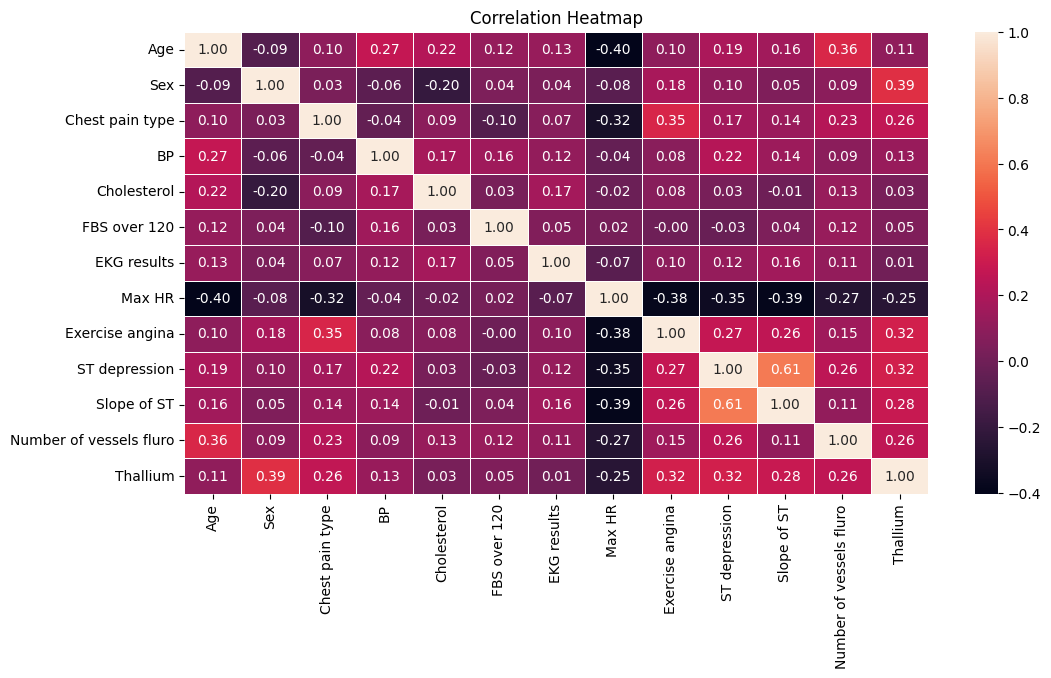

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [11]:
X = df[['Age','Sex','Chest pain type','BP','Cholesterol','Max HR']]
y = df['Heart Disease']

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.preprocessing import MinMaxScaler
mn=MinMaxScaler()
X_train_scaled=mn.fit_transform(X_train)
X_test_scaled=mn.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred_lr=lr.predict(X_test_scaled)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
y_pred_knn=knn.predict(X_test_scaled)

In [18]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [19]:
y_pred_nb=nb.predict(X_test)

In [20]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini',random_state=42)
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred_dt=dt.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy Score for the Models:\n")
acc_lr = accuracy_score(y_test, y_pred_lr) * 100
acc_knn = accuracy_score(y_test, y_pred_knn) * 100
acc_nb = accuracy_score(y_test, y_pred_nb) * 100
acc_dt = accuracy_score(y_test, y_pred_dt) * 100
print("Logistic Regression : {:.3f}%".format(acc_lr))
print("KNN                : {:.3f}%".format(acc_knn))
print("Naive Bayes        : {:.3f}%".format(acc_nb))
print("Decision Tree      : {:.3f}%".format(acc_dt))
print("\nClassification Reports:\n")
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("KNN:\n", classification_report(y_test, y_pred_knn))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))
print("Decision Tree:\n", classification_report(y_test, y_pred_dt))


Accuracy Score for the Models:

Logistic Regression : 83.333%
KNN                : 74.074%
Naive Bayes        : 85.185%
Decision Tree      : 68.519%

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

     Absence       0.82      0.94      0.87        33
    Presence       0.88      0.67      0.76        21

    accuracy                           0.83        54
   macro avg       0.85      0.80      0.81        54
weighted avg       0.84      0.83      0.83        54

KNN:
               precision    recall  f1-score   support

     Absence       0.74      0.88      0.81        33
    Presence       0.73      0.52      0.61        21

    accuracy                           0.74        54
   macro avg       0.74      0.70      0.71        54
weighted avg       0.74      0.74      0.73        54

Naive Bayes:
               precision    recall  f1-score   support

     Absence       0.86      0.91      0.88        33
    Presence       0

In [28]:
models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Naive Bayes": nb,
    "Decision Tree": dt
}

accuracies = {
    "Logistic Regression": acc_lr,
    "KNN": acc_knn,
    "Naive Bayes": acc_nb,
    "Decision Tree": acc_dt
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]
best_model_accuracy = accuracies[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy: {:.3f}%".format(best_model_accuracy))


Best Model: Naive Bayes
Best Accuracy: 85.185%


In [29]:
sex_map = {
    "male": 1,
    "female": 0
}
cp_map = {
    "typical": 1,
    "atypical": 2,
    "non-anginal": 3,
    "asymptomatic": 4
}

In [25]:
print("\nEnter patient details for prediction:")
age = int(input("Enter age: "))
sex_input = input("Enter sex (male/female): ")
if sex_input.lower() == "male":
    sex = 1
else:
    sex = 0
cp = int(input("Enter chest pain type (1–4): "))
bp = float(input("Enter blood pressure: "))
chol = float(input("Enter cholesterol: "))
maxHR = float(input("Enter max heart rate: "))


Enter patient details for prediction:


Enter age:  45
Enter sex (male/female):  male
Enter chest pain type (1–4):  4
Enter blood pressure:  25
Enter cholesterol:  56
Enter max heart rate:  52


In [30]:
new_data = np.array([[age,sex,cp,bp,chol,maxHR]])
prediction = best_model.predict(new_data)
print(prediction[0])

Presence


C:\Users\mohit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [31]:
df['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64